### Problem Statement : Design and implement CNN for image classification.
### • Select	a	suitable	image	classification	dataset	(medical	engineering, agricultural, etc.).
### • Optimized with different hyper-parameters including learning rate, filter size, no. of layers, optimizers, dropouts, etc.


In [1]:
# Import necessary modules
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


In [2]:
# ==========================================
# 1. Load and Prepare Dataset
# ==========================================
print("\n--- Step 1: Loading and Preparing Dataset ---")
# Loading the inbuilt MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizing the images to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshaping images to specify 1 channel (grayscale) -> (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print(f"x_train shape: {x_train.shape} - {x_train.shape[0]} training samples")
print(f"x_test shape: {x_test.shape} - {x_test.shape[0]} testing samples")


--- Step 1: Loading and Preparing Dataset ---
x_train shape: (60000, 28, 28, 1) - 60000 training samples
x_test shape: (10000, 28, 28, 1) - 10000 testing samples


In [3]:
# ==========================================
# 2. Define CNN Architecture
# ==========================================
print("\n--- Step 2: Defining CNN Architecture ---")
# Hyper-parameters incorporated here: filter size (3x3), multiple layers, dropouts
model = Sequential([
    # Layer 1: Convolutional Layer with 3x3 filter size
    Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Layer 2: Convolutional Layer with 3x3 filter size
    Conv2D(64, kernel_size=(3, 3), activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    
    # Flattening the 2D arrays for fully connected layers
    Flatten(),
    
    # Dropout layer to prevent overfitting (Hyper-parameter)
    Dropout(0.5),
    
    # Fully connected Dense layer
    Dense(128, activation="relu"),
    
    # Output layer: 10 units for 10 classes (0-9) using softmax
    Dense(10, activation="softmax")
])

model.summary()


--- Step 2: Defining CNN Architecture ---


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ==========================================
# 3. Compile the Model
# ==========================================
print("\n--- Step 3: Compiling the Model ---")
# Hyper-parameter: Custom Learning Rate
learning_rate = 0.001
optimizer = Adam(learning_rate=learning_rate)

model.compile(
    optimizer=optimizer, 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)


--- Step 3: Compiling the Model ---


In [5]:
# ==========================================
# 4. Hyperparameter Tuning and Training
# ==========================================
print("\n--- Step 4: Training the Model ---")
# Setting up Early Stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=3, # Stop after 3 epochs of no improvement
    restore_best_weights=True
)

# Hyper-parameters: batch size, epochs
batch_size = 64
epochs = 15

# Training the model with a 20% validation split
history = model.fit(
    x_train, y_train, 
    batch_size=batch_size, 
    epochs=epochs, 
    validation_split=0.2, 
    callbacks=[early_stopping]
)


--- Step 4: Training the Model ---
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8463 - loss: 0.4972 - val_accuracy: 0.9816 - val_loss: 0.0593
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9747 - loss: 0.0829 - val_accuracy: 0.9862 - val_loss: 0.0446
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9826 - loss: 0.0540 - val_accuracy: 0.9883 - val_loss: 0.0428
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9862 - loss: 0.0447 - val_accuracy: 0.9893 - val_loss: 0.0362
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9870 - loss: 0.0384 - val_accuracy: 0.9913 - val_loss: 0.0332
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9876 - loss: 0.0385 - val_accuracy: 0.9902 - val_loss: 0.0332
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9892 - loss: 0.0310 - val_accuracy: 0.9913 - val_loss: 0.0289
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - 


--- Step 5: Evaluating and Testing ---
Final Test Loss: 0.0241
Final Test Accuracy: 99.16%


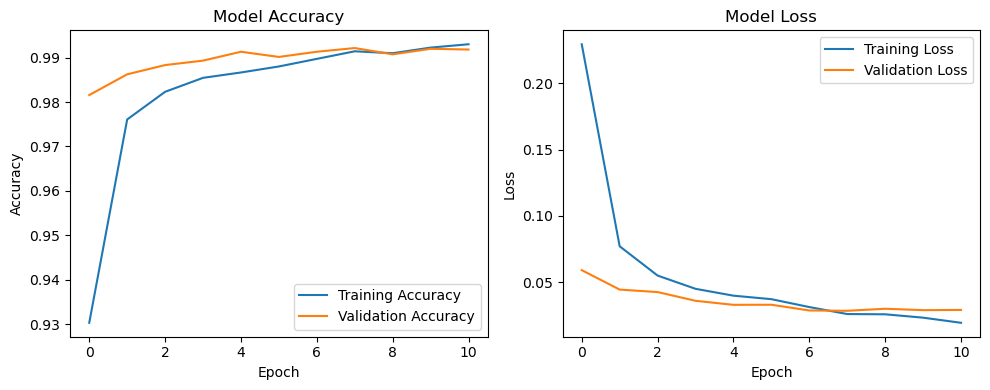

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


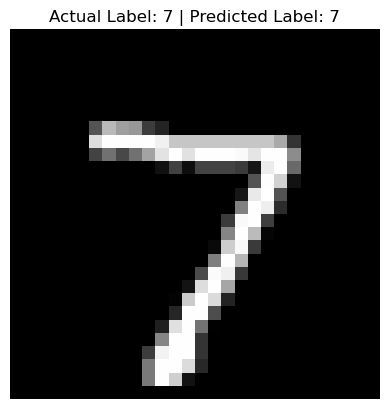

In [6]:
# ==========================================
# 5. Evaluate and Test
# ==========================================
print("\n--- Step 5: Evaluating and Testing ---")
# Evaluating the model on unseen test data
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")

# Plotting the Training and Validation accuracy over epochs
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


# Making a sample prediction
sample_image = x_test[0]
sample_label = y_test[0]

# Expand dimensions to create a "batch" of 1 for the predict function
prediction = model.predict(np.expand_dims(sample_image, axis=0))
predicted_class = np.argmax(prediction)

# Displaying the actual vs predicted image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Actual Label: {sample_label} | Predicted Label: {predicted_class}")
plt.axis('off')
plt.show()